Accuracy: 0.7896233120113717

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



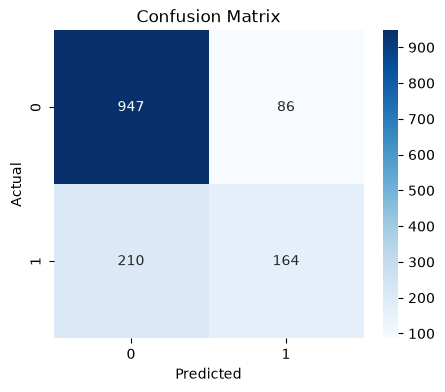

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# =========================
# 3. DATA CLEANING
# =========================
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# =========================
# 4. SPLIT DATA
# =========================
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. MODEL (RANDOM FOREST)
# =========================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 6. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 7. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =========================
# 8. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 9. SAVE MODEL
# =========================
pickle.dump(model, open("churn_model.pkl", "wb"))

In [2]:
import pickle

pickle.dump(model, open("churn_model.pkl", "wb"))
pickle.dump(X.columns, open("feature_columns.pkl", "wb"))